In [77]:
import pandas as pd 
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import  Ridge, Lasso, RidgeCV, LassoCV, ElasticNet, ElasticNetCV, LogisticRegression
from sklearn.model_selection import train_test_split
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import accuracy_score, confusion_matrix,roc_auc_score, roc_curve
import matplotlib.pyplot as plt
# import scikitplot as skl
import seaborn as sns

In [78]:
sns.set()

In [79]:
# Reading the Data and show the top head data 
data = pd.read_csv("./data/Algerian_forest_fires_dataset_UPDATE.csv")
data.head(5)

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0,not fire
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire


In [80]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
day,244.0,15.754098,8.825059,1.0,8.000,16.00,23.000,31.0
month,244.0,7.500000,1.112961,6.0,7.000,7.50,8.000,9.0
year,244.0,2012.000000,0.000000,2012.0,2012.000,2012.00,2012.000,2012.0
Temperature,244.0,32.172131,3.633843,22.0,30.000,32.00,35.000,42.0
RH,244.0,61.938525,14.884200,21.0,52.000,63.00,73.250,90.0
Ws,244.0,15.504098,2.810178,6.0,14.000,15.00,17.000,29.0
Rain,244.0,0.760656,1.999406,0.0,0.000,0.00,0.500,16.8
FFMC,244.0,77.887705,14.337571,28.6,72.075,83.50,88.300,96.0
DMC,244.0,14.673361,12.368039,0.7,5.800,11.30,20.750,65.9
ISI,244.0,4.774180,4.175318,0.0,1.400,3.50,7.300,19.0


Rain and ISI exhibit highly skewed distributions. For example, the mean of Rain is 0.76, while the median is 0.00 and the maximum is 16.8. This indicates a right-skewed distribution. Therefore, before performing feature scaling or normalization, it is important to transform these features to reduce skewness.

Key Features to Transform (before modeling or scaling):

Rain → Heavily right-skewed → use log1p(Rain)

ISI → Moderate to heavy skew → use sqrt(ISI) or log1p(ISI)

DMC → Moderate skew → use sqrt(DMC)

BUI → Moderate skew → use sqrt(BUI)

In [81]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          244 non-null    int64  
 1   month        244 non-null    int64  
 2   year         244 non-null    int64  
 3   Temperature  244 non-null    int64  
 4    RH          244 non-null    int64  
 5    Ws          244 non-null    int64  
 6   Rain         244 non-null    float64
 7   FFMC         244 non-null    float64
 8   DMC          244 non-null    float64
 9   DC           244 non-null    object 
 10  ISI          244 non-null    float64
 11  BUI          244 non-null    float64
 12  FWI          244 non-null    object 
 13  Classes      243 non-null    object 
dtypes: float64(5), int64(6), object(3)
memory usage: 26.8+ KB


--------------------------------------------------------------------------------
* Row count	244 वटा data छन्

* ✅ Column count	14 वटा columns छन्

* ⚠️ Missing value	Classes column मा 1 वटा missing value छ

* 🧠 Data types	int64 (6), float64 (5), object (3) छन्

* ❗ Object column ध्यान दिनुपर्ने	FWI, DC र Classes लाई confirm गर्नुपर्छ — string हो या numeric formatted wrongly

* 💾 Memory	Dataset सानो छ, RAM मा सजिलै process गर्न सकिन्छ

---------------------------------------------------
🔧 के गर्न सकिन्छ?

* FWI र DC को value जाँच्न:

    data['FWI'].unique()

    data['DC'].unique()


* यदि numeric हुनुपर्ने हो भने convert गर्नुहोस्:

    data['FWI'] = pd.to_numeric(data['FWI'], errors='coerce')

    data['DC'] = pd.to_numeric(data['DC'], errors='coerce')


* Missing value handle गर्नुहोस्:

    data['Classes'].isnull().sum()
    
    data = data.dropna(subset=['Classes'])  # वा fillna()

In [82]:
data.FWI.unique()

array(['0.5', '0.4', '0.1', '0', '2.5', '7.2', '7.1', '0.3', '0.9', '5.6',
       '0.2', '1.4', '2.2', '2.3', '3.8', '7.5', '8.4', '10.6', '15',
       '13.9', '3.9', '12.9', '1.7', '4.9', '6.8', '3.2', '8', '0.6',
       '3.4', '0.8', '3.6', '6', '10.9', '4', '8.8', '2.8', '2.1', '1.3',
       '7.3', '15.3', '11.3', '11.9', '10.7', '15.7', '6.1', '2.6', '9.9',
       '11.6', '12.1', '4.2', '10.2', '6.3', '14.6', '16.1', '17.2',
       '16.8', '18.4', '20.4', '22.3', '20.9', '20.3', '13.7', '13.2',
       '19.9', '30.2', '5.9', '7.7', '9.7', '8.3', '0.7', '4.1', '1',
       '3.1', '1.9', '10', '16.7', '1.2', '5.3', '6.7', '9.5', '12',
       '6.4', '5.2', '3', '9.6', '4.7', 'fire   ', '14.1', '9.1', '13',
       '17.3', '30', '25.4', '16.3', '9', '14.5', '13.5', '19.5', '12.6',
       '12.7', '21.6', '18.8', '10.5', '5.5', '14.8', '24', '26.3',
       '12.2', '18.1', '24.5', '26.9', '31.1', '30.3', '26.1', '16',
       '19.4', '2.7', '3.7', '10.3', '5.7', '9.8', '19.3', '17.5', '15.4',

In [83]:
# convert the value to numeirc 
data['FWI'] = pd.to_numeric(data['FWI'], errors='coerce')
data.FWI.unique()


array([ 0.5,  0.4,  0.1,  0. ,  2.5,  7.2,  7.1,  0.3,  0.9,  5.6,  0.2,
        1.4,  2.2,  2.3,  3.8,  7.5,  8.4, 10.6, 15. , 13.9,  3.9, 12.9,
        1.7,  4.9,  6.8,  3.2,  8. ,  0.6,  3.4,  0.8,  3.6,  6. , 10.9,
        4. ,  8.8,  2.8,  2.1,  1.3,  7.3, 15.3, 11.3, 11.9, 10.7, 15.7,
        6.1,  2.6,  9.9, 11.6, 12.1,  4.2, 10.2,  6.3, 14.6, 16.1, 17.2,
       16.8, 18.4, 20.4, 22.3, 20.9, 20.3, 13.7, 13.2, 19.9, 30.2,  5.9,
        7.7,  9.7,  8.3,  0.7,  4.1,  1. ,  3.1,  1.9, 10. , 16.7,  1.2,
        5.3,  6.7,  9.5, 12. ,  6.4,  5.2,  3. ,  9.6,  4.7,  nan, 14.1,
        9.1, 13. , 17.3, 30. , 25.4, 16.3,  9. , 14.5, 13.5, 19.5, 12.6,
       12.7, 21.6, 18.8, 10.5,  5.5, 14.8, 24. , 26.3, 12.2, 18.1, 24.5,
       26.9, 31.1, 30.3, 26.1, 16. , 19.4,  2.7,  3.7, 10.3,  5.7,  9.8,
       19.3, 17.5, 15.4, 15.2,  6.5])

In [84]:
data['DC'] = pd.to_numeric(data['DC'], errors='coerce')
data.DC.unique()

array([  7.6,   7.1,   6.9,  14.2,  22.2,  30.5,  38.3,  38.8,  46.3,
        54.3,  61.4,  17. ,   7.8,   7.4,   8. ,  16. ,  27.1,  31.6,
        39.5,  47.7,  55.8,  63.8,  71.8,  80.3,  88.5,  84.4,  92.8,
         8.6,   8.3,   9.2,  18.5,  27.9,  37. ,  40.4,  49.8,   9.3,
        18.7,  27.7,  37.2,  22.9,  25.5,  34.1,  43.1,  52.8,  62.1,
        71.5,  79.9,  71.3,  79.7,  88.7,  98.6, 108.5, 117.8, 127. ,
       136. , 145.7,  10.2,  10. ,  19.8,  29.7,  39.1,  48.6,  47. ,
        57. ,  67. ,  77. ,  75.1,  85.1,  94.7,  92.5,  90.4, 100.7,
       110.9, 120.9, 130.6, 141.1, 151.3, 161.5, 171.3, 181.3, 190.6,
       200.2, 210.4, 220.4, 180.4,   8.7,   7.5,   7. ,  15.7,  24. ,
        32.2,  30.1,   8.4,   8.9,  16.6,   7.3,  24.3,  33.1,  41.3,
        49.3,  57.9,  41.4,  30.4,  15.2,   7.7,  16.3,  24.9,   8.8,
         8.2,  15.4,  17.6,  26.3,  28.9,  14.7,  22.5,  37.8,  18.4,
        25.6,  34.5,  43.3,  52.4,  36.7,   8.5,  17.8,  27.3,  36.8,
        46.4,  45.1,

In [85]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          244 non-null    int64  
 1   month        244 non-null    int64  
 2   year         244 non-null    int64  
 3   Temperature  244 non-null    int64  
 4    RH          244 non-null    int64  
 5    Ws          244 non-null    int64  
 6   Rain         244 non-null    float64
 7   FFMC         244 non-null    float64
 8   DMC          244 non-null    float64
 9   DC           243 non-null    float64
 10  ISI          244 non-null    float64
 11  BUI          244 non-null    float64
 12  FWI          243 non-null    float64
 13  Classes      243 non-null    object 
dtypes: float64(7), int64(6), object(1)
memory usage: 26.8+ KB


In [86]:
data.columns

Index(['day', 'month', 'year', 'Temperature', ' RH', ' Ws', 'Rain ', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes  '],
      dtype='object')

In [96]:
# trip the column
data.columns = data.columns.str.strip()
data.columns

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes'],
      dtype='object')

In [95]:
data['Classes'].unique()

array(['not fire', 'fire'], dtype=object)

In [94]:
from sklearn.preprocessing import OneHotEncoder
data['Classes'] = data['Classes'].str.strip()
data = data.dropna(subset=['Classes'])

# Step 2: Copy after cleaning
df = data.copy()

# Step 3: One-hot encoding
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded_array = encoder.fit_transform(df[['Classes']])
encoded_df = pd.DataFrame(encoded_array, columns=encoder.get_feature_names_out(['Classes']))

# Step 4: Merge
final_data = pd.concat([df, encoded_df], axis=1)
final_data

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Classes_fire,Classes_not fire
0,1.0,6.0,2012.0,29.0,57.0,18.0,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0.0,1.0
1,2.0,6.0,2012.0,29.0,61.0,13.0,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0.0,1.0
2,3.0,6.0,2012.0,26.0,82.0,22.0,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0.0,1.0
3,4.0,6.0,2012.0,25.0,89.0,13.0,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0.0,1.0
4,5.0,6.0,2012.0,27.0,77.0,16.0,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
240,27.0,9.0,2012.0,28.0,87.0,15.0,4.4,41.1,6.5,8.0,0.1,6.2,0.0,not fire,0.0,1.0
241,28.0,9.0,2012.0,27.0,87.0,29.0,0.5,45.9,3.5,7.9,0.4,3.4,0.2,not fire,0.0,1.0
242,29.0,9.0,2012.0,24.0,54.0,18.0,0.1,79.7,4.3,15.2,1.7,5.1,0.7,not fire,0.0,1.0
243,30.0,9.0,2012.0,24.0,64.0,15.0,0.2,67.3,3.8,16.5,1.2,4.8,0.5,not fire,NaN,NaN


In [90]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 243 entries, 0 to 243
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          243 non-null    int64  
 1   month        243 non-null    int64  
 2   year         243 non-null    int64  
 3   Temperature  243 non-null    int64  
 4   RH           243 non-null    int64  
 5   Ws           243 non-null    int64  
 6   Rain         243 non-null    float64
 7   FFMC         243 non-null    float64
 8   DMC          243 non-null    float64
 9   DC           243 non-null    float64
 10  ISI          243 non-null    float64
 11  BUI          243 non-null    float64
 12  FWI          243 non-null    float64
 13  Classes      243 non-null    object 
dtypes: float64(7), int64(6), object(1)
memory usage: 36.6+ KB


In [91]:
data.isnull().sum()

day            0
month          0
year           0
Temperature    0
RH             0
Ws             0
Rain           0
FFMC           0
DMC            0
DC             0
ISI            0
BUI            0
FWI            0
Classes        0
dtype: int64

C:\Users\s230250\AppData\Local\Temp\ipykernel_31212\3418471729.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data[column])
C:\Users\s230250\AppData\Local\Temp\ipykernel_31212\3418471729.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data[column])
C:\Users\s230250\AppData\Local\Temp\ip

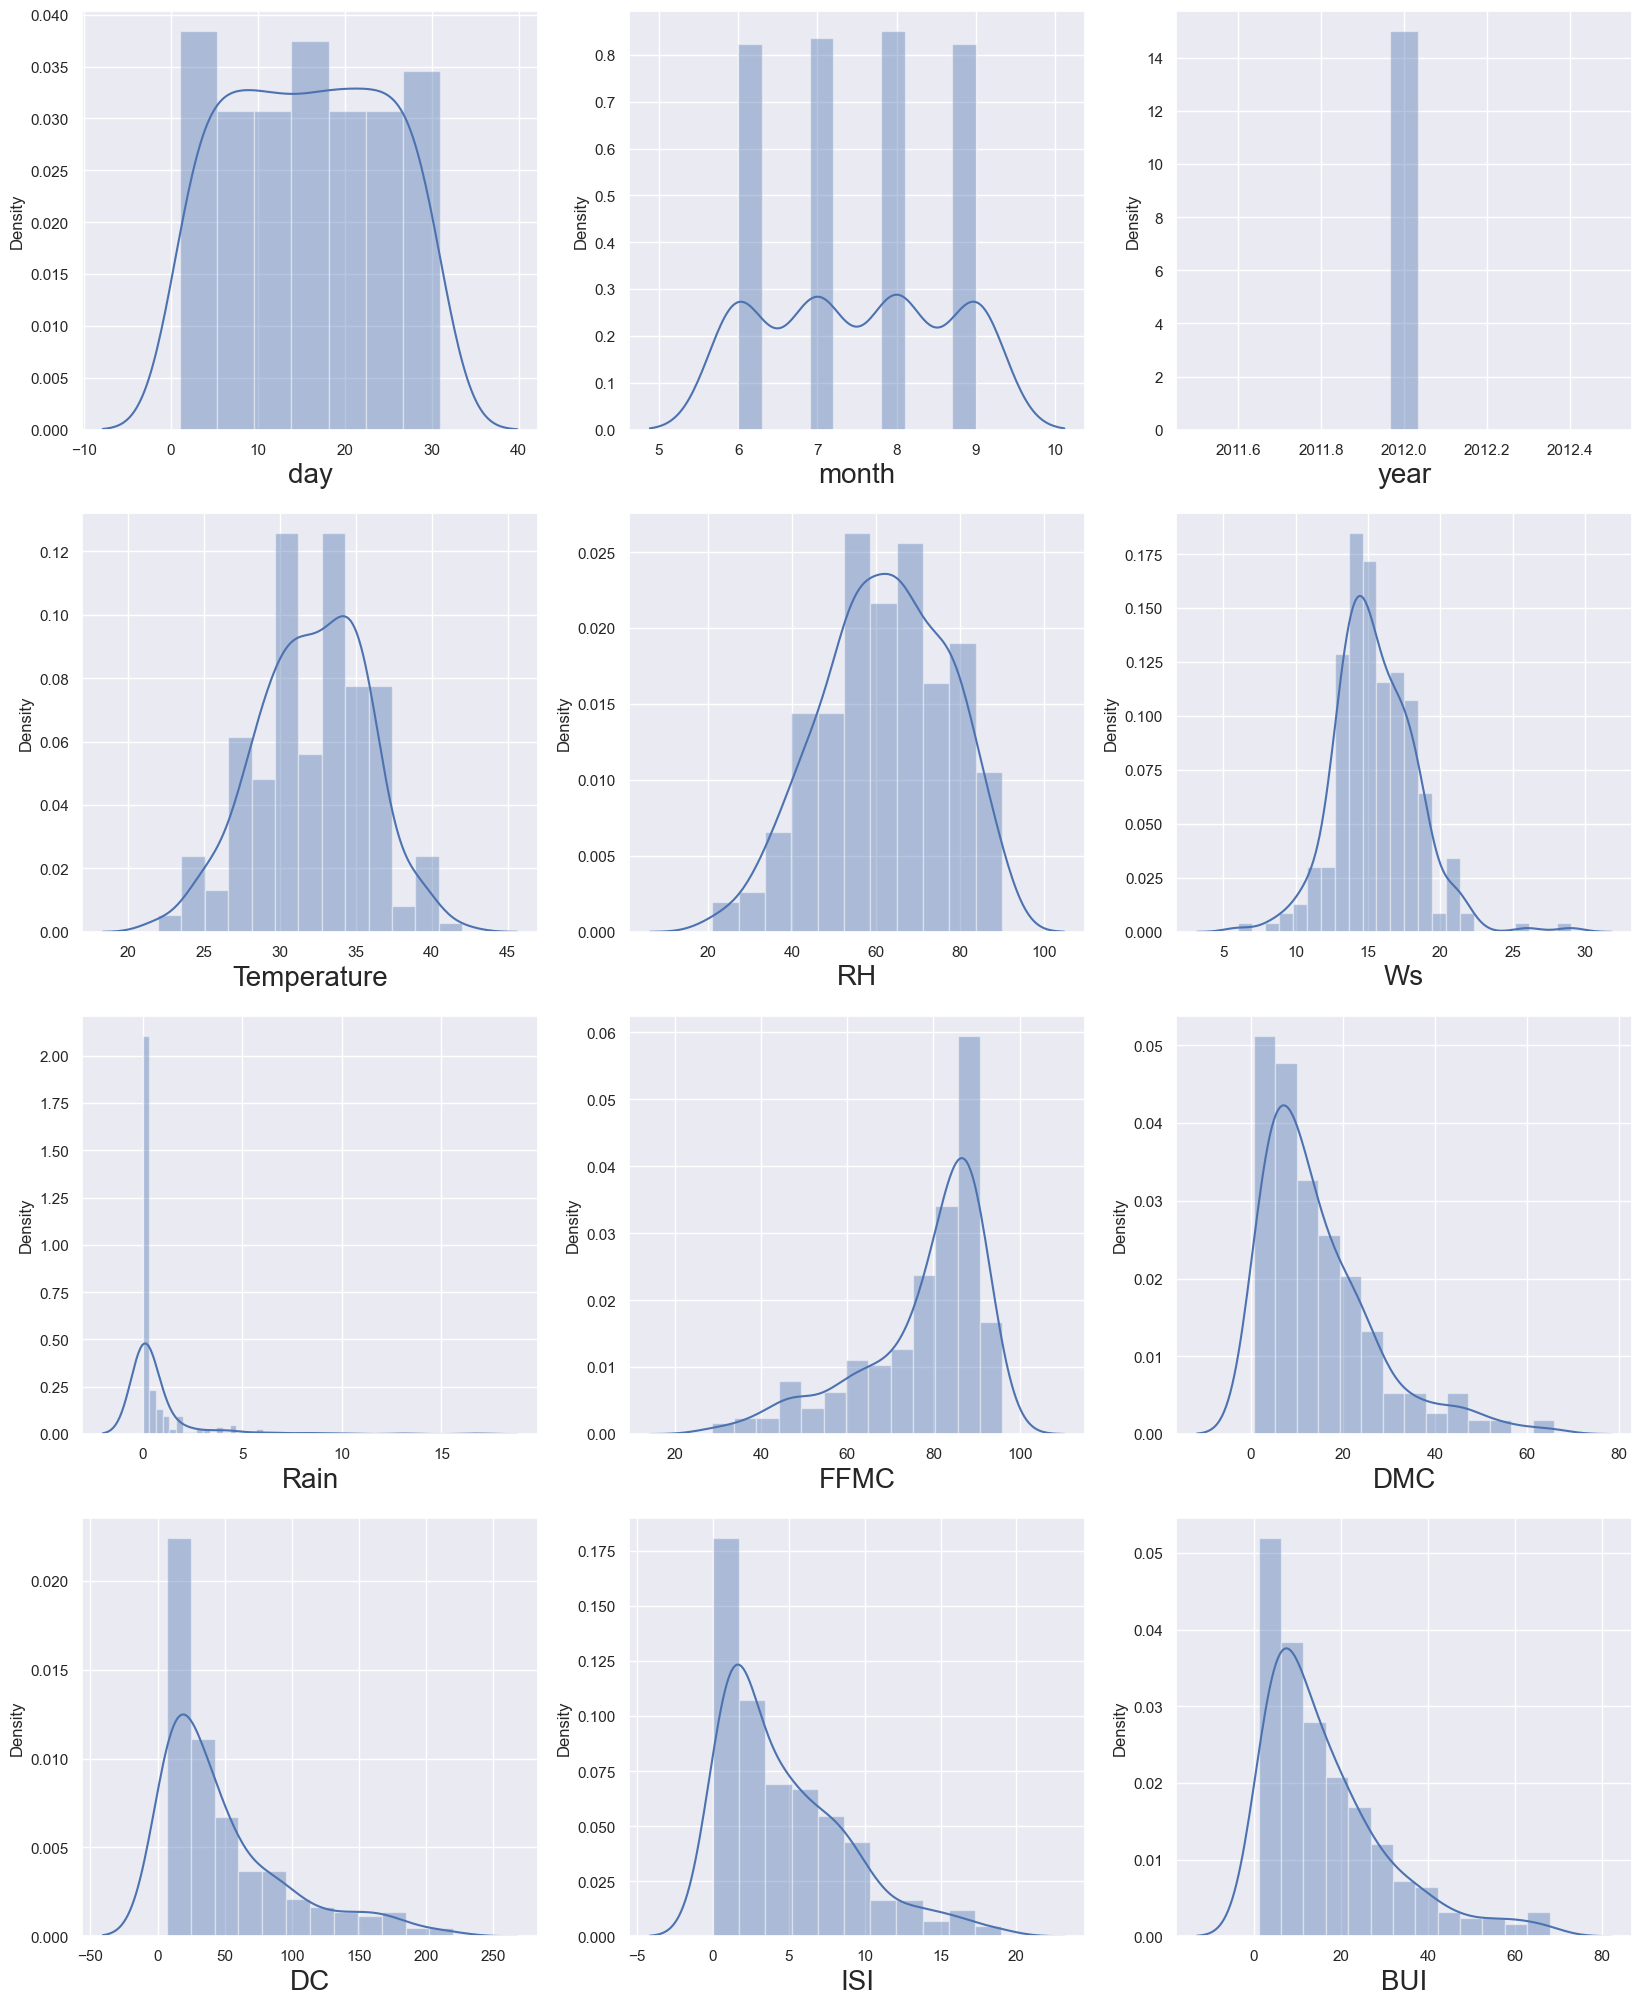

In [39]:
#let's see how data is distributed for every column
plt.figure(figsize=(20,25), facecolor = 'white')
plotnumber = 1
for column in data :
    if plotnumber<=12:
        ax = plt.subplot(4,3, plotnumber)
        sns.distplot(data[column])
        plt.xlabel(column, fontsize = 20)
    plotnumber+=1
plt.show()


| Feature                    | Distribution Observation                 | Distribution Type           |
| -------------------------- | ---------------------------------------- | --------------------------- |
| **day**                    | Flat histogram, almost uniform           | ✅ Uniform                   |
| **month**                  | Discrete peaks at 6, 7, 8, 9             | ✅ Discrete                  |
| **year**                   | Single spike at 2012                     | ❌ Constant (No variance)    |
| **Temperature**            | Bell-shaped, symmetric                   | ✅ Normal (Gaussian)         |
| **RH (Relative Humidity)** | Almost symmetric but slightly wide       | ➖ Near-normal               |
| **Ws (Wind Speed)**        | Peak around 14–16, slightly right-skewed | ➖ Slight Right-skew         |
| **Rain**                   | High spike at 0, long tail               | ⚠️ **Heavily Right-skewed** |
| **FFMC**                   | Strong right tail, peak near 90–100      | ⚠️ **Right-skewed**         |
| **DMC**                    | Peak at low values, long right tail      | ⚠️ **Right-skewed**         |
| **DC**                     | Long tail to the right, skewed heavily   | ⚠️ **Right-skewed**         |
| **ISI**                    | Peak at low values (0–5), long tail      | ⚠️ **Heavily Right-skewed** |
| **BUI**                    | Strong skew to the right                 | ⚠️ **Right-skewed**         |


✅ निष्कर्ष (Summary in Nepali)

🔢 day र month → Discrete data हुन्, continuous modeling का लागि encoding गर्न सकिन्छ (one-hot या cyclical).

📅 year → Constant छ, model मा काम लाग्दैन → remove गर्नु ठीक हुन्छ।

🌡 Temperature, RH → लगभग normal distribution छन् → scaling गर्न सजिलो हुन्छ।

🌬 Ws (Wind speed) → थोरै skewed छ तर transform नगरे पनि राम्रो performance आउन सक्छ।

🌧 Rain, ISI, DMC, BUI, FFMC, DC → Heavily right-skewed छन् ⇒ log, sqrt, या Box-Cox transform गर्नुपर्छ।

💡 के गर्नु उपयुक्त हुन्छ?
    काम	गर्ने
    Constant column हटाउने	year हटाउने

    Skewed feature transform गर्ने	Rain, ISI, DMC, BUI, FFMC, DC

    Normal features scale गर्ने	Temperature, RH, Ws → use StandardScaler
    
    Encode categorical	month, day लाई One-hot वा Cyclical encode गर्न सकिन्छ

In [40]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, FunctionTransformer

In [41]:
# Define the column groups 
# Drop the constant column(year)
data = data.drop(columns=['year'])
#skewed features 
skewed_feature = ['Rain', 'ISI', 'BUI', 'FFMC', 'DC']
#normal feature (to be scaled only)
normal_features = ['Temperature', 'RH', 'Ws']